# Fixed-policy Fisher eigenspectrum

Inspect artifacts produced by `python -m fisher_analysis.run_fisher_analysis`. Configure a result directory and optional width subset below; relative paths are resolved from the repository root.

The notebook validates the selected Fisher archives, prints their spectral summary, and saves and displays raw, trace-normalized, cumulative-trace, and optional NPG-damped views.

In [1]:
RESULTS_DIR = "fisher_analysis/results/hopper_width_sweep"
WIDTHS = None  # None uses every width listed in RESULTS_DIR/config.json; or use e.g. [4, 16].
OUTPUT_DIR = "fisher_analysis/results/hopper_width_sweep"

RAW_TITLE = "Undamped empirical Fisher eigenspectrum"
NORMALIZED_TITLE = "Trace-normalized Fisher eigenspectrum"
CUMULATIVE_TITLE = "Cumulative Fisher trace"
DAMPING_TITLE = "Fisher spectrum after NPG diagonal damping"

SHOW_NPG_DAMPING = True
NPG_DAMPING = 0.01
DPI = 180

In [2]:
# M: Locate the repository and resolve every configured path consistently.
# A: Searching parent directories makes execution independent of the notebook's working directory.

import csv
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display

working_dir = Path.cwd().resolve()
repo_root = next(
    (path for path in (working_dir, *working_dir.parents) if (path / "fisher_analysis").is_dir()),
    None,
)
if repo_root is None:
    raise FileNotFoundError("Could not locate the repository root containing fisher_analysis")

def from_repo_root(path):
    path = Path(path).expanduser()
    return path.resolve() if path.is_absolute() else (repo_root / path).resolve()

results_dir = from_repo_root(RESULTS_DIR)
output_dir = from_repo_root(OUTPUT_DIR)
if not results_dir.is_dir():
    raise FileNotFoundError(f"Fisher results directory does not exist: {results_dir}")
if NPG_DAMPING < 0:
    raise ValueError("NPG_DAMPING must be non-negative")
if DPI <= 0:
    raise ValueError("DPI must be positive")
output_dir.mkdir(parents=True, exist_ok=True)
print(f"results: {results_dir}")
print(f"outputs: {output_dir}")

results: /Users/adelella/Documents/Useful/More/pj/vanilla-policy-gradient/fisher_analysis/results/hopper_width_sweep
outputs: /Users/adelella/Documents/Useful/More/pj/vanilla-policy-gradient/fisher_analysis/results/hopper_width_sweep


In [3]:
# M: Load the requested spectra and verify that their saved arrays agree.
# A: Validation catches incomplete, non-finite, asymmetric, or mismatched artifacts before plotting.

config_path = results_dir / "config.json"
summary_path = results_dir / "summary.csv"
if not config_path.is_file():
    raise FileNotFoundError(f"Missing Fisher configuration: {config_path}")
if not summary_path.is_file():
    raise FileNotFoundError(f"Missing Fisher summary: {summary_path}")

with config_path.open(encoding="utf-8") as handle:
    config = json.load(handle)
configured_widths = [int(width) for width in config.get("widths", [])]
selected_widths = configured_widths if WIDTHS is None else [int(width) for width in WIDTHS]
if not selected_widths:
    raise ValueError("Select at least one network width")
if len(selected_widths) != len(set(selected_widths)):
    raise ValueError("WIDTHS must not contain duplicates")
unknown_widths = [width for width in selected_widths if width not in configured_widths]
if unknown_widths:
    raise ValueError(f"Widths not present in config.json: {unknown_widths}")

with summary_path.open(newline="", encoding="utf-8") as handle:
    summary_by_width = {int(row["width"]): row for row in csv.DictReader(handle)}

required_arrays = {
    "fisher",
    "eigenvalues",
    "trace_normalized_eigenvalues",
    "cumulative_explained_trace",
    "total_sample_count",
    "rank_tolerance",
    "psd_tolerance",
}
spectra = {}
for width in selected_widths:
    archive_path = results_dir / f"fisher_width_{width}.npz"
    if not archive_path.is_file():
        raise FileNotFoundError(f"Missing Fisher archive: {archive_path}")
    with np.load(archive_path, allow_pickle=False) as archive:
        missing = required_arrays.difference(archive.files)
        if missing:
            raise ValueError(f"{archive_path} is missing arrays: {sorted(missing)}")
        data = {name: np.array(archive[name], copy=True) for name in required_arrays}

    fisher = data["fisher"]
    eigenvalues = data["eigenvalues"]
    dimension = eigenvalues.size
    if fisher.shape != (dimension, dimension) or eigenvalues.ndim != 1:
        raise ValueError(
            f"Invalid Fisher/eigenvalue shapes for width {width}: "
            f"fisher={fisher.shape}, eigenvalues={eigenvalues.shape}"
        )
    for name in ("fisher", "eigenvalues", "trace_normalized_eigenvalues", "cumulative_explained_trace"):
        if not np.all(np.isfinite(data[name])):
            raise ValueError(f"{archive_path} contains non-finite values in {name}")
    if data["trace_normalized_eigenvalues"].shape != eigenvalues.shape:
        raise ValueError(f"Normalized spectrum shape does not match width {width}")
    if data["cumulative_explained_trace"].shape != eigenvalues.shape:
        raise ValueError(f"Cumulative spectrum shape does not match width {width}")
    if np.any(eigenvalues[:-1] < eigenvalues[1:]):
        raise ValueError(f"Eigenvalues are not descending for width {width}")
    np.testing.assert_allclose(
        fisher,
        fisher.T,
        rtol=0.0,
        atol=float(data["psd_tolerance"]),
        err_msg=f"Fisher is not symmetric for width {width}",
    )
    np.testing.assert_allclose(
        np.trace(fisher),
        eigenvalues.sum(),
        rtol=1e-10,
        err_msg=f"Fisher trace does not match eigenvalues for width {width}",
    )
    if width not in summary_by_width:
        raise ValueError(f"summary.csv has no row for width {width}")
    spectra[width] = data

columns = [
    "width", "matrix_dimension", "sample_count", "trace", "numerical_rank",
    "effective_rank", "stable_rank", "positive_condition_number",
    "components_90", "components_95", "components_99",
]
missing_columns = [column for column in columns if any(column not in summary_by_width[width] for width in selected_widths)]
if missing_columns:
    raise ValueError(f"summary.csv is missing columns: {missing_columns}")
table = [" | ".join(columns), " | ".join(["---"] * len(columns))]
table.extend(" | ".join(summary_by_width[width][column] for column in columns) for width in selected_widths)
display(Markdown("\n".join(table)))
print(f"loaded widths: {selected_widths}")

width | matrix_dimension | sample_count | trace | numerical_rank | effective_rank | stable_rank | positive_condition_number | components_90 | components_95 | components_99
--- | --- | --- | --- | --- | --- | --- | --- | --- | --- | ---
4 | 86 | 29389 | 41.103991386352305 | 86 | 6.163801238282999 | 1.5594224458144519 | 248576602.41348568 | 6 | 8 | 15
8 | 198 | 11549 | 35.02286618120014 | 198 | 7.298236201684814 | 1.8587877766738452 | 15552684684.614876 | 7 | 9 | 15
16 | 518 | 21107 | 47.15708761940382 | 518 | 9.930454088342808 | 1.9403570411319413 | 9634799315.660788 | 10 | 13 | 25

loaded widths: [4, 8, 16]


saved: /Users/adelella/Documents/Useful/More/pj/vanilla-policy-gradient/fisher_analysis/results/hopper_width_sweep/raw_eigenspectrum.png


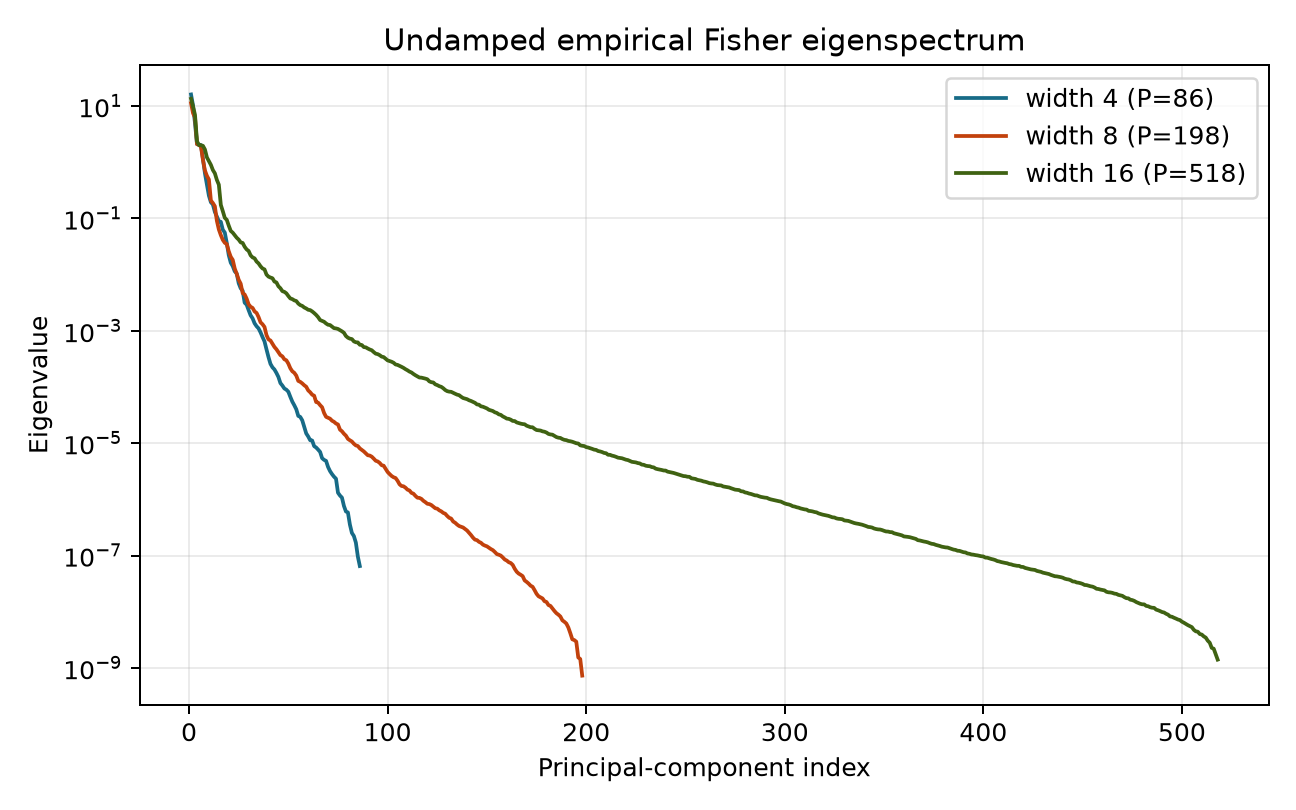

saved: /Users/adelella/Documents/Useful/More/pj/vanilla-policy-gradient/fisher_analysis/results/hopper_width_sweep/trace_normalized_eigenspectrum.png


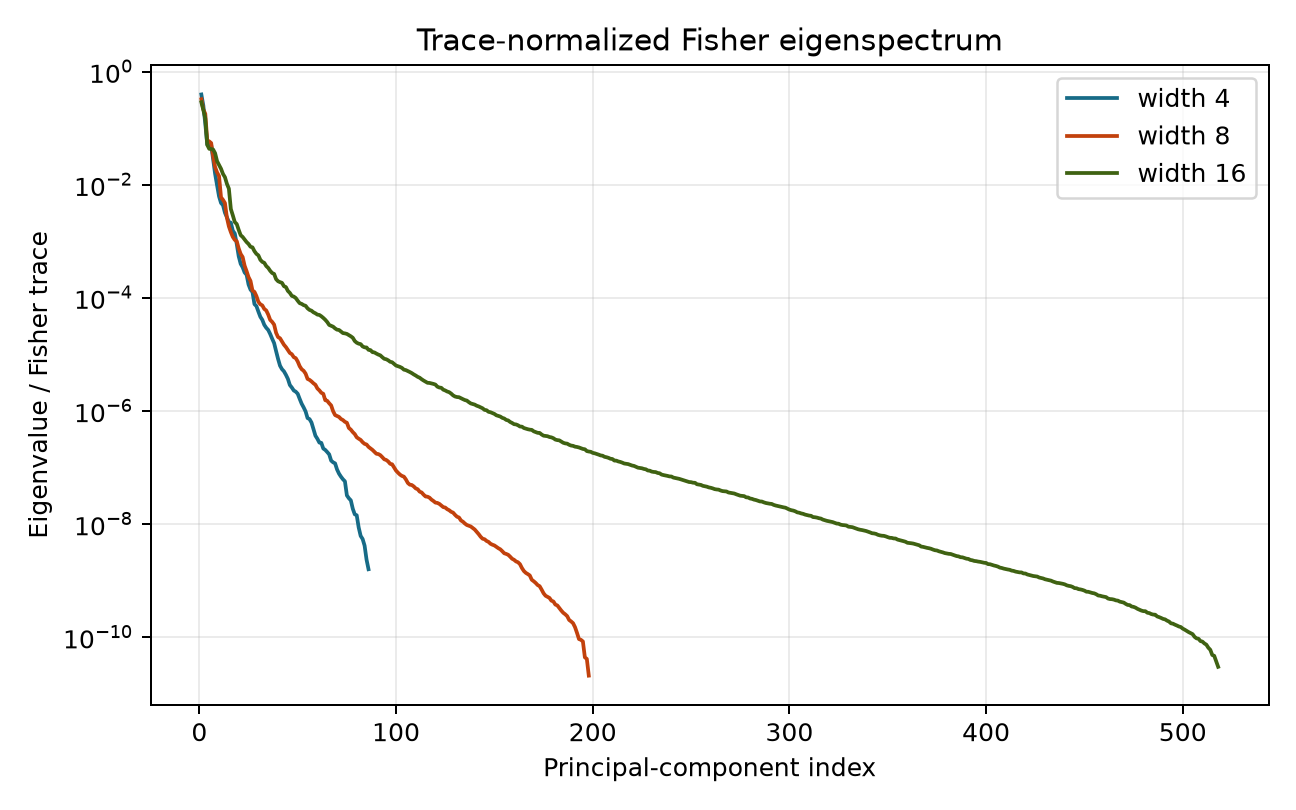

saved: /Users/adelella/Documents/Useful/More/pj/vanilla-policy-gradient/fisher_analysis/results/hopper_width_sweep/cumulative_explained_trace.png


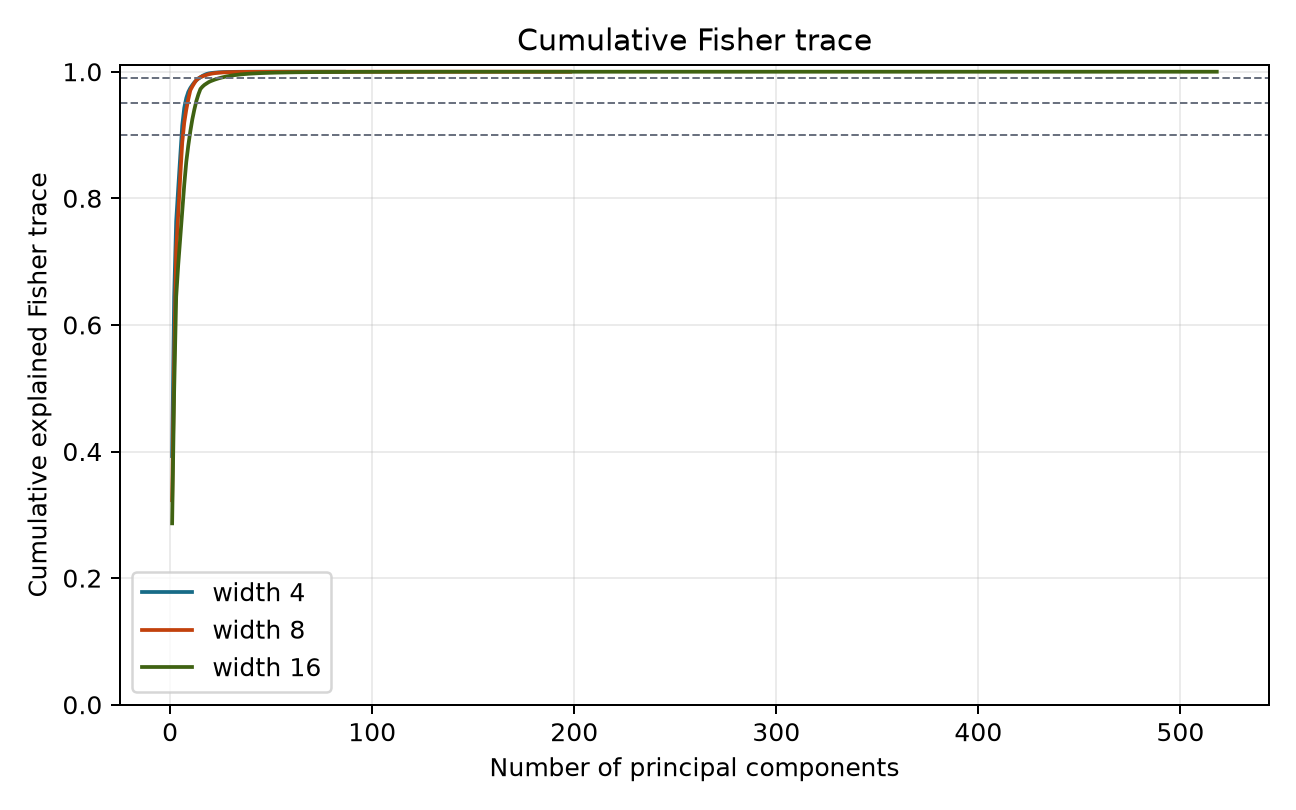

width 4: damped condition number = 1615.62
width 8: damped condition number = 1132.39
width 16: damped condition number = 1352.12
saved: /Users/adelella/Documents/Useful/More/pj/vanilla-policy-gradient/fisher_analysis/results/hopper_width_sweep/damped_eigenspectrum.png


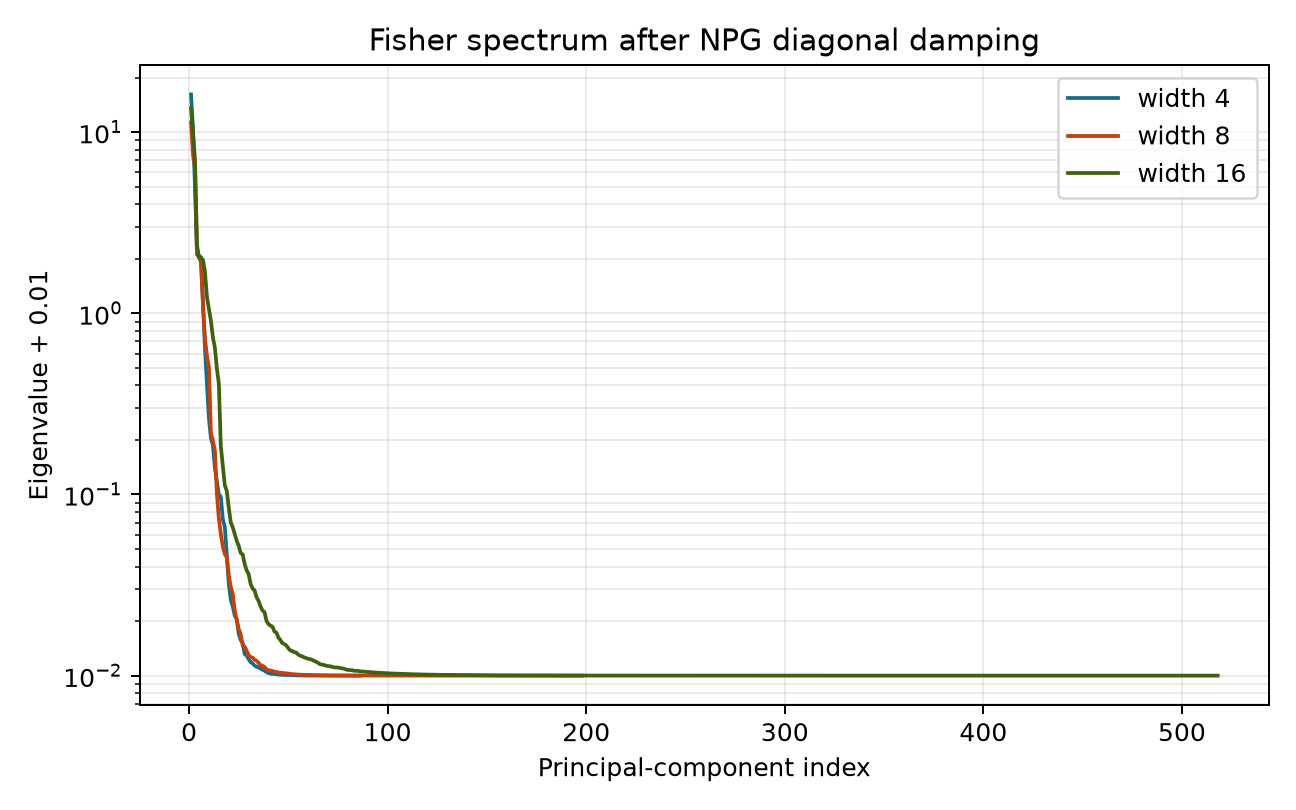

In [4]:
# M: Generate every configured view from the validated spectra.
# A: Each figure uses consistent width colors, is saved to OUTPUT_DIR, and is displayed inline.

colors = ["#176B87", "#C2410C", "#3F6212", "#7E22CE", "#374151"]

def finish_plot(figure, axis, filename):
    axis.grid(True, which="both", alpha=0.25)
    axis.legend()
    figure.tight_layout()
    path = output_dir / filename
    figure.savefig(path, dpi=DPI)
    plt.close(figure)
    print(f"saved: {path}")
    display(Image(filename=str(path)))
    return path

figure, axis = plt.subplots(figsize=(7.2, 4.5))
for index, (width, data) in enumerate(spectra.items()):
    values = data["eigenvalues"]
    floor = max(float(data["rank_tolerance"]), np.finfo(np.float64).tiny)
    axis.semilogy(
        np.arange(1, values.size + 1),
        np.maximum(values, floor),
        color=colors[index % len(colors)],
        label=f"width {width} (P={values.size})",
    )
axis.set(xlabel="Principal-component index", ylabel="Eigenvalue", title=RAW_TITLE)
raw_path = finish_plot(figure, axis, "raw_eigenspectrum.png")

figure, axis = plt.subplots(figsize=(7.2, 4.5))
for index, (width, data) in enumerate(spectra.items()):
    values = data["trace_normalized_eigenvalues"]
    trace = float(np.trace(data["fisher"]))
    floor = float(data["rank_tolerance"]) / trace if trace > 0 else np.finfo(np.float64).tiny
    axis.semilogy(
        np.arange(1, values.size + 1),
        np.maximum(values, floor),
        color=colors[index % len(colors)],
        label=f"width {width}",
    )
axis.set(
    xlabel="Principal-component index",
    ylabel="Eigenvalue / Fisher trace",
    title=NORMALIZED_TITLE,
)
normalized_path = finish_plot(figure, axis, "trace_normalized_eigenspectrum.png")

figure, axis = plt.subplots(figsize=(7.2, 4.5))
for index, (width, data) in enumerate(spectra.items()):
    cumulative = data["cumulative_explained_trace"]
    axis.plot(
        np.arange(1, cumulative.size + 1),
        cumulative,
        color=colors[index % len(colors)],
        label=f"width {width}",
    )
for level in (0.90, 0.95, 0.99):
    axis.axhline(level, color="#6B7280", linewidth=0.8, linestyle="--")
axis.set(
    xlabel="Number of principal components",
    ylabel="Cumulative explained Fisher trace",
    title=CUMULATIVE_TITLE,
    ylim=(0, 1.01),
)
cumulative_path = finish_plot(figure, axis, "cumulative_explained_trace.png")

damping_path = None
if SHOW_NPG_DAMPING:
    figure, axis = plt.subplots(figsize=(7.2, 4.5))
    for index, (width, data) in enumerate(spectra.items()):
        shifted = data["eigenvalues"] + NPG_DAMPING
        condition_number = shifted[0] / shifted[-1] if shifted[-1] > 0 else np.inf
        print(f"width {width}: damped condition number = {condition_number:.6g}")
        axis.semilogy(
            np.arange(1, shifted.size + 1),
            shifted,
            color=colors[index % len(colors)],
            label=f"width {width}",
        )
    axis.set(
        xlabel="Principal-component index",
        ylabel=f"Eigenvalue + {NPG_DAMPING:g}",
        title=DAMPING_TITLE,
    )
    damping_path = finish_plot(figure, axis, "damped_eigenspectrum.png")
else:
    print("NPG damping view disabled")